En este código se reunen las figuras que no aparecen explícitamente en los códigos del guiado de robots.

#### **Visualización de la intersección de superficies $\phi_i=0$, para la curva $\boldsymbol{f}(\omega)=[cos(\omega),sen(\omega)]$**

Se muestra la proyección de C sobre el subespacio definido por las coordenadas espaciales.


In [8]:
import numpy as np
import matplotlib.pyplot as plt

def f(w):
    fx = np.cos(w)
    fy = np.sin(w)

    return np.array([fx,fy])

def phi(x):
    
    return x-f(w)


x = np.linspace(-np.pi, np.pi, 100)
y = np.linspace(-np.pi, np.pi, 100)
w = np.linspace(-np.pi, np.pi, 100)

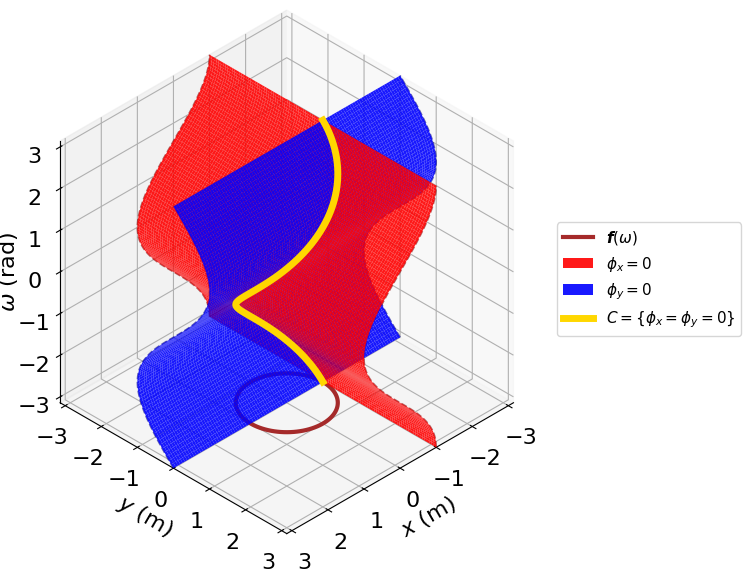

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Convierte una malla (X,Y,Z) en una lista de cuadrilateros (caras)
def to_quads(X, Y, Z):
    tl = np.stack([X[:-1,:-1], Y[:-1,:-1], Z[:-1,:-1]], axis=-1)
    tr = np.stack([X[:-1,1:],  Y[:-1,1:],  Z[:-1,1:]],  axis=-1)
    br = np.stack([X[1:,1:],   Y[1:,1:],   Z[1:,1:]],   axis=-1)
    bl = np.stack([X[1:,:-1],  Y[1:,:-1],  Z[1:,:-1]],  axis=-1)
    return np.stack([tl,tr,br,bl], axis=2).reshape(-1,4,3)

# Superficie phi_x = 0  ->  x = f_x(w), libre en y
Yg, Wg = np.meshgrid(y, w)
qr = to_quads(f(Wg)[0], Yg, Wg)

# Superficie phi_y = 0  ->  y = f_y(w), libre en x
Xg, Wg2 = np.meshgrid(x, w)
qb = to_quads(Xg, f(Wg2)[1], Wg2)

# Las dos laminas en una sola coleccion -> se ocluyen entre si por profundidad
quads = np.concatenate([qr, qb], axis=0)
cols  = (['red']*len(qr)) + (['blue']*len(qb))

fc = f(w)

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')
ax.set_proj_type('ortho')

# Proyeccion (primero, queda debajo)
ax.plot(fc[0], fc[1], np.full_like(w, w[0]), color='brown', lw=3, zorder=0)

surf = Poly3DCollection(quads, facecolors=cols, alpha=0.9,
                        linewidths=0, edgecolors='none')
ax.add_collection3d(surf)

# Bordes de las superficies (lineas discontinuas)
ax.plot(f(w)[0], np.full_like(w, y[0]),  w, color='darkred', lw=1.2, ls='--', alpha=0.6)
ax.plot(f(w)[0], np.full_like(w, y[-1]), w, color='darkred', lw=1.2, ls='--', alpha=0.6)
ax.plot(np.full_like(w, x[0]),  f(w)[1], w, color='darkblue', lw=1.2, ls='--', alpha=0.6)
ax.plot(np.full_like(w, x[-1]), f(w)[1], w, color='darkblue', lw=1.2, ls='--', alpha=0.6)

# Interseccion
ax.plot(fc[0], fc[1], w, color='gold', lw=5, zorder=10)

ax.set_xlabel(r'$x\ (\mathrm{m})$', fontsize=16)
ax.set_ylabel(r'$y\ (\mathrm{m})$', fontsize=16)
ax.set_zlabel(r'$\omega\ (\mathrm{rad})$', fontsize=16, labelpad=2)
ax.tick_params(labelsize=16)

ax.set_xlim(x.min(), x.max()); ax.set_ylim(y.min(), y.max()); ax.set_zlim(w.min(), w.max())

# Leyenda manual modificada (color='brown' para f(omega))
handles = [
    Line2D([], [], color='brown', lw=3, label=r'$\boldsymbol{f}(\omega)$'),
    Patch(facecolor='red',  alpha=0.9, label=r'$\phi_x = 0$'),
    Patch(facecolor='blue', alpha=0.9, label=r'$\phi_y = 0$'),
    Line2D([], [], color='gold', lw=5, label=r'$C=\{\phi_x=\phi_y=0\}$'),
]
ax.legend(handles=handles, fontsize=11, loc='center left', bbox_to_anchor=(1.0, 0.5))

ax.set_box_aspect((1,1,1))
ax.view_init(elev=np.degrees(np.arctan(1/np.sqrt(2))), azim=45)

fig.subplots_adjust(left=0.12, right=0.78)
plt.show()

#### **Visualización de función de error $\phi(\xi)$**

Se muestra la forma de las superficies $\phi(x_i,\omega)$ para el caso de robots moviéndose en dos dimensiones, con la curva parametrizada $f(\omega)$. 

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def f(w):
    fx = np.cos(w)
    fy = np.sin(w)

    return np.array([fx,fy])

def phi(x,f):
    
    return x-f


x = np.linspace(-np.pi, np.pi, 100)
y = np.linspace(-np.pi, np.pi, 100)
w = np.linspace(-np.pi, np.pi, 100)

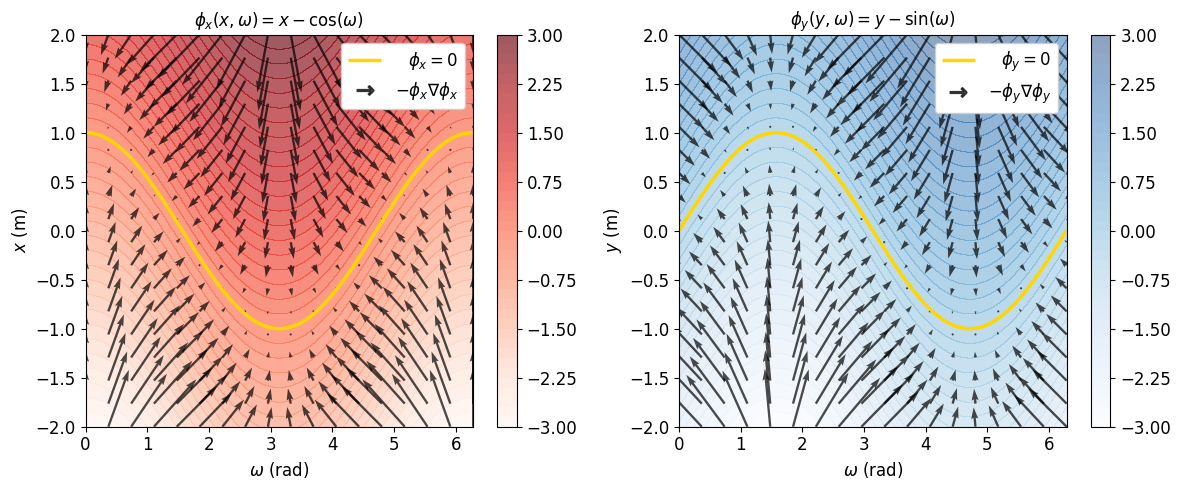

In [11]:
from matplotlib.lines import Line2D

# Grid fino (para los contornos)
x_vals = np.linspace(-2, 2, 200)
y_vals = np.linspace(-2, 2, 200)
w_vals = np.linspace(0, 2 * np.pi, 200)

# Grid grueso (para los vectores)
x_q = np.linspace(-2, 2, 18)
y_q = np.linspace(-2, 2, 18)
w_q = np.linspace(0, 2 * np.pi, 18)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

def texto_a_la_derecha(leg):
    fig.canvas.draw()
    rows = leg._legend_box.get_children()[1].get_children()[0].get_children()
    widths = [t.get_window_extent().width for t in leg.get_texts()]  # pixeles
    maxw = max(widths)
    px_a_pt = 72.0 / fig.dpi   # row.sep esta en puntos, no pixeles
    for row, w in zip(rows, widths):
        row.sep += (maxw - w) * px_a_pt
    fig.canvas.draw()

# --- phi_x ---
X, W = np.meshgrid(x_vals, w_vals)
Z_x = phi(X, f(W)[0])
axes[0].contourf(W, X, Z_x, levels=50, cmap='Reds', alpha=0.65)
cs_x = axes[0].contour(W, X, Z_x, levels=[0], colors='gold', linewidths=2.5)
axes[0].colorbar = plt.colorbar(axes[0].collections[0], ax=axes[0])
axes[0].colorbar.ax.tick_params(labelsize=12)
# campo -phi * grad(phi)
Xq, Wq = np.meshgrid(x_q, w_q)
Zq = phi(Xq, f(Wq)[0])
U = -Zq * np.sin(Wq)   # componente omega
V = -Zq * 1.0          # componente x
axes[0].quiver(Wq, Xq, U, V, color='black', alpha=0.7, scale=20, width=0.006)
vec_proxy_x = Line2D([], [], color='black', alpha=0.7, marker=r'$\rightarrow$',
                     markersize=12, linestyle='None')
handles_x, _ = cs_x.legend_elements()
leg_x = axes[0].legend(handles_x + [vec_proxy_x], [r'$\phi_x = 0$', r'$-\phi_x \nabla\phi_x$'],
                       loc='upper right', fontsize=12, framealpha=1.0)
texto_a_la_derecha(leg_x)
axes[0].set_xlabel(r'$\omega\ (\mathrm{rad})$', fontsize=12)
axes[0].set_ylabel(r'$x\ (\mathrm{m})$', fontsize=12)
axes[0].set_title(r'$\phi_x(x, \omega) = x - \cos(\omega)$', fontsize=12)
axes[0].tick_params(labelsize=12)
# --- phi_y ---
Y, W = np.meshgrid(y_vals, w_vals)
Z_y = phi(Y, f(W)[1])
axes[1].contourf(W, Y, Z_y, levels=50, cmap='Blues', alpha=0.45)
cs_y = axes[1].contour(W, Y, Z_y, levels=[0], colors='gold', linewidths=2.5)
axes[1].colorbar = plt.colorbar(axes[1].collections[0], ax=axes[1])
axes[1].colorbar.ax.tick_params(labelsize=12)
Yq, Wq = np.meshgrid(y_q, w_q)
Zq = phi(Yq, f(Wq)[1])
U = -Zq * (-np.cos(Wq))   # componente omega
V = -Zq * 1.0             # componente y
axes[1].quiver(Wq, Yq, U, V, color='black', alpha=0.7, scale=20, width=0.006)
vec_proxy_y = Line2D([], [], color='black', alpha=0.7, marker=r'$\rightarrow$',
                     markersize=12, linestyle='None')
handles_y, _ = cs_y.legend_elements()
leg_y = axes[1].legend(handles_y + [vec_proxy_y], [r'$\phi_y = 0$', r'$-\phi_y \nabla\phi_y$'],
                       loc='upper right', fontsize=12, framealpha=1.0)
texto_a_la_derecha(leg_y)
axes[1].set_xlabel(r'$\omega\ (\mathrm{rad})$', fontsize=12)
axes[1].set_ylabel(r'$y\ (\mathrm{m})$', fontsize=12)
axes[1].set_title(r'$\phi_y(y, \omega) = y - \sin(\omega)$', fontsize=12)
axes[1].tick_params(labelsize=12)
plt.tight_layout()
plt.show()

#### **Representación de la amplitud de desviación de las variables frente a $\alpha$**

Se muestra gráficamente la amplitud frente a $\alpha$, en escala logarítmica en base 10 para $\alpha$.

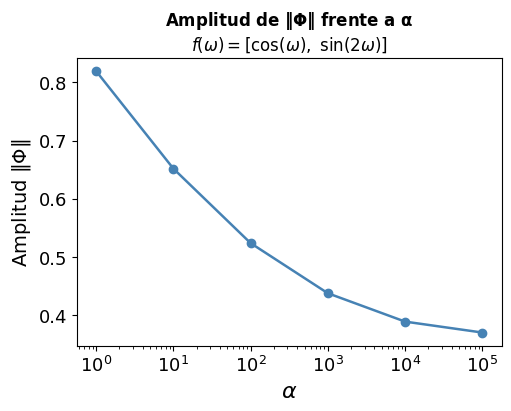

In [12]:
alpha = np.array([100000, 10000, 1000, 100, 10, 1])
phi   = np.array([0.3699, 0.3887, 0.4375, 0.5237, 0.6519, 0.8196])

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)

ax.plot(alpha, phi, 'o-', color='steelblue', lw=1.8)
ax.set_xscale('log')
ax.set_xlabel(r'$\alpha$', fontsize=16)
ax.set_ylabel(r'Amplitud $\|\Phi\|$', fontsize=14)
ax.tick_params(axis='both', labelsize=13)
ax.set_title(r"$\mathbf{Amplitud\ de\ \|\Phi\|\ frente\ a\ \alpha}$" + "\n"
             + r"$f(\omega) = \left[\cos(\omega),\ \sin(2\omega)\right]$")
plt.show()

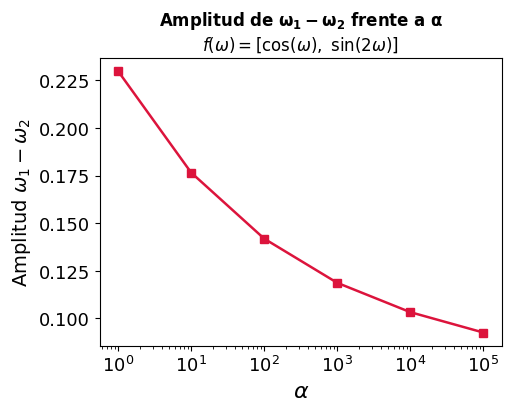

In [13]:
alpha        = np.array([100000, 10000, 1000, 100, 10, 1])
amplitud_dist = np.array([0.0926, 0.1033, 0.1187, 0.1419, 0.1766, 0.2299])

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)

ax.plot(alpha, amplitud_dist, 's-', color='crimson', lw=1.8)
ax.set_xscale('log')
ax.set_xlabel(r'$\alpha$', fontsize=16)
ax.set_ylabel(r'Amplitud $\omega_1-\omega_2$', fontsize=14)
ax.tick_params(axis='both', labelsize=13)
ax.set_title(r"$\mathbf{Amplitud\ de\ \omega_1-\omega_2\ frente\ a\ \alpha}$" + "\n"
             + r"$f(\omega) = \left[\cos(\omega),\ \sin(2\omega)\right]$")
plt.show()

#### **Ajuste de los datos**

Se ajustan los datos a una ley de potencias $f(\alpha) = \frac{K}{\alpha^a}

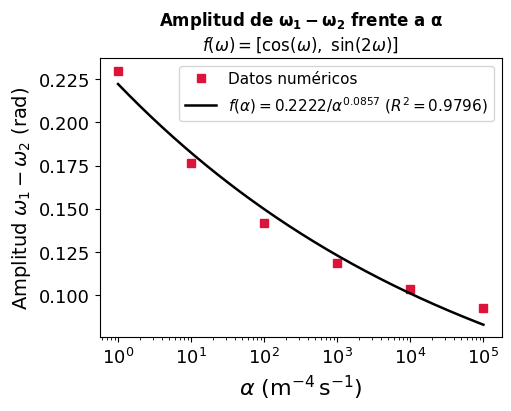

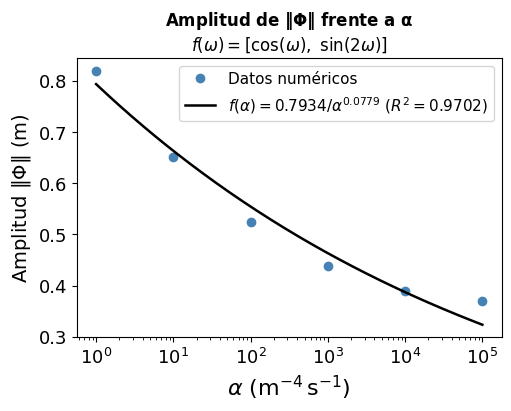

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Definición del modelo estricto (K / alpha^a)
def power_law_strict(x, K, a):
    return K / (x**a)

# 2. Función genérica para ajuste y visualización
def plot_ajuste(x, y, p0_estimado, ylabel, titulo, color_marker, marker_style):
    # Ajuste paramétrico
    popt, _ = curve_fit(power_law_strict, x, y, p0=p0_estimado)
    K_opt, a_opt = popt
    
    # Cálculo de R^2
    y_pred = power_law_strict(x, *popt)
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r_squared = 1 - (ss_res / ss_tot)
    
    # Leyenda actualizada con f(alpha)
    etiqueta_ajuste = rf'$f(\alpha) = {K_opt:.4f}/\alpha^{{{a_opt:.4f}}}$ ($R^2={r_squared:.4f}$)'
    
    # Datos para la curva teórica
    x_fit = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
    y_fit = power_law_strict(x_fit, *popt)
    
    # Generación de la gráfica
    fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
    
    # Puntos numéricos
    ax.plot(x, y, marker_style, color=color_marker, markersize=6, label='Datos numéricos', linestyle='None')
    
    # Curva teórica
    ax.plot(x_fit, y_fit, 'k-', lw=1.8, label=etiqueta_ajuste)
    
    # Configuración de ejes
    ax.set_xscale('log')
    ax.set_xlabel(r'$\alpha\ (\mathrm{m^{-4}\,s^{-1}})$', fontsize=16)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.tick_params(axis='both', labelsize=13)
    ax.set_title(titulo)
    ax.legend(fontsize=11)
    
    plt.show()

# 3. Definición de los datos
alpha = np.array([100000, 10000, 1000, 100, 10, 1])
amplitud_dist = np.array([0.0926, 0.1033, 0.1187, 0.1419, 0.1766, 0.2299])
phi = np.array([0.3699, 0.3887, 0.4375, 0.5237, 0.6519, 0.8196])

# 4. Ejecución para el Bloque 1 (Amplitud w1-w2)
titulo_dist = (r"$\mathbf{Amplitud\ de\ \omega_1-\omega_2\ frente\ a\ \alpha}$" + "\n"
               + r"$f(\omega) = \left[\cos(\omega),\ \sin(2\omega)\right]$")
plot_ajuste(x=alpha, 
            y=amplitud_dist, 
            p0_estimado=[0.2, 0.1], 
            ylabel=r'Amplitud $\omega_1-\omega_2$ (rad)', 
            titulo=titulo_dist, 
            color_marker='crimson', 
            marker_style='s')

# 5. Ejecución para el Bloque 2 (Amplitud Phi)
titulo_phi = (r"$\mathbf{Amplitud\ de\ \|\Phi\|\ frente\ a\ \alpha}$" + "\n"
              + r"$f(\omega) = \left[\cos(\omega),\ \sin(2\omega)\right]$")
plot_ajuste(x=alpha, 
            y=phi, 
            p0_estimado=[0.8, 0.1], 
            ylabel=r'Amplitud $\|\Phi\|$ (m)', 
            titulo=titulo_phi, 
            color_marker='steelblue', 
            marker_style='o')